# Trabalho 09 — Histograma sobre imagem
## Escala de cinza e canais RGB, via arquivo CSV

**Disciplina:** Computação Gráfica / Processamento de Imagens Digitais
**Professor:** André Alessandro Stein
**Aluno:** Igor
**Instituição:** IFC — Campus Rio do Sul

### Enunciado

> **a)** Gerar histograma (gráfico) sobre a imagem em escala de cinza.
>
> **b)** Gerar histograma (gráfico) sobre a imagem RGB, cada canal de cor
> separado.
>
> *Obs.: dica — criar arquivo `.csv` e então gerar o gráfico sobre estes dados.*

### O pipeline adotado

A dica do professor sugere uma separação entre **extração** e **visualização**,
e o notebook a leva a sério: os gráficos não são plotados a partir dos arrays em
memória, mas dos dados relidos do CSV.

    imagem  ->  contagem  ->  CSV em disco  ->  releitura  ->  gráfico

Fazer o caminho completo tem duas vantagens concretas. Primeiro, o CSV é um
entregável independente, que abre no Excel ou LibreOffice sem depender do
notebook. Segundo, a releitura funciona como verificação: se o gráfico gerado a
partir do arquivo coincide com os dados originais, está provado que o CSV foi
gravado corretamente.

### Referências

- STEIN, A. A.; HECK, C. *Processamento de Imagens Digitais* — slides da disciplina.
- LOPES, J. M. Brisson. *Formatos de Imagem*. DEI — IST, Lisboa, 2003 (reed. 2013).

## 1. Fundamentação

### O que é um histograma de imagem

O histograma é a **contagem de quantos píxeis possuem cada nível de
intensidade**. Para uma imagem de 8 bits, é um vetor de 256 posições:

    h[i] = número de píxeis cuja intensidade vale i,  para i = 0, 1, ..., 255

Duas propriedades decorrem imediatamente da definição:

- A soma de todas as posições é o total de píxeis: `Σ h[i] = largura × altura`.
  Serve como verificação de que nenhum píxel foi perdido ou contado duas vezes.
- Dividindo por esse total obtém-se o **histograma normalizado**, que é uma
  distribuição de probabilidade: a chance de um píxel escolhido ao acaso ter
  cada intensidade.

### O que o histograma preserva e o que descarta

O histograma é uma descrição **puramente estatística**: registra quantos píxeis
de cada tom existem, mas não onde estão. Duas imagens completamente diferentes
podem ter histogramas idênticos — basta embaralhar os píxeis de uma delas.

Essa perda da informação espacial é justamente o que torna o histograma útil.
Ele resume 640.000 píxeis em 256 números, permitindo diagnosticar rapidamente
brilho, contraste e distribuição tonal, e é a base de operações como
equalização, realce de contraste e limiarização automática — o método de Otsu
usado na Atividade 05-2, por exemplo, trabalha exclusivamente sobre o histograma,
sem tocar na imagem.

### Cuidado: níveis com frequência zero

Um erro comum é montar o histograma com `np.unique`, que devolve apenas os
valores **presentes** na imagem. Os níveis de frequência zero somem do resultado,
e o gráfico fica com o eixo horizontal deformado — barras adjacentes passam a
representar níveis não consecutivos.

O correto é `np.bincount(..., minlength=256)`, que garante as 256 posições
independentemente de quais aparecem. Este trabalho usa uma imagem em que o
problema é real: como se verá, vários níveis têm contagem zero.

### Histogramas de imagens coloridas

Uma imagem RGB não possui um histograma único. O procedimento usual, e o que o
enunciado pede, é tratar **cada canal como uma imagem independente** e gerar três
histogramas de 256 posições.

Isso descarta a correlação entre canais — o histograma não diz quais valores de R
ocorrem junto de quais valores de B. Uma descrição completa exigiria um
histograma tridimensional de 256³ posições, inviável na prática e quase sempre
desnecessário.

In [1]:
# Bibliotecas e configuração

import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

BASE = Path.cwd()
ENTRADA = BASE / "entrada"
SAIDA = BASE / "saida"
SAIDA.mkdir(exist_ok=True)

ARQUIVO_CINZA = ENTRADA / "EntradaEscalaCinza.pgm"
ARQUIVO_RGB = ENTRADA / "EntradaRGB.ppm"

MAXVAL = 255
N_NIVEIS = MAXVAL + 1       # 256 posições no histograma

print(f"PGM existe : {ARQUIVO_CINZA.exists()}  ({ARQUIVO_CINZA.name})")
print(f"PPM existe : {ARQUIVO_RGB.exists()}  ({ARQUIVO_RGB.name})")
print(f"Níveis     : {N_NIVEIS} (0 a {MAXVAL})")

PGM existe : True  (EntradaEscalaCinza.pgm)
PPM existe : True  (EntradaRGB.ppm)
Níveis     : 256 (0 a 255)


In [2]:
# --- Leitores PGM e PPM ---

def _fluxo_tokens(arquivo):
    """Gera tokens do arquivo, descartando comentários iniciados por '#'."""
    for linha in arquivo:
        util = linha.split("#", 1)[0]
        for token in util.split():
            yield token


def ler_pnm(caminho):
    """
    Lê um arquivo PGM (P2) ou PPM (P3).

    Devolve (matriz, maxval, magic). A matriz é 2D para P2 e
    (altura, largura, 3) para P3.
    """
    with open(caminho, "r", encoding="ascii") as f:
        it = _fluxo_tokens(f)

        magic = next(it)
        if magic not in ("P2", "P3"):
            raise ValueError(f"Magic number não suportado: {magic!r}")

        largura, altura, maxval = (int(next(it)) for _ in range(3))
        canais = 3 if magic == "P3" else 1
        esperados = largura * altura * canais

        dados = np.fromiter(map(int, it), dtype=np.int32, count=esperados)

    if dados.size != esperados:
        raise ValueError(f"Esperados {esperados} valores, lidos {dados.size}")

    forma = (altura, largura, 3) if canais == 3 else (altura, largura)
    return dados.reshape(forma), maxval, magic

Imagem          Magic     Dimensões      Píxeis     Valores
------------------------------------------------------------
Escala cinza       P2       800x800     640,000     640,000
RGB                P3       800x800     640,000   1,920,000


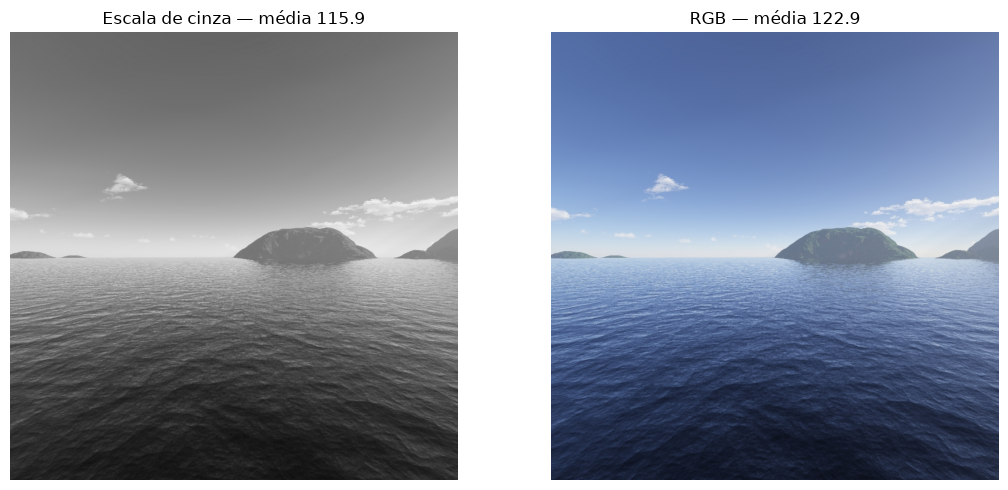

In [3]:
# --- Leitura das duas imagens ---

cinza, mv_cinza, magic_cinza = ler_pnm(ARQUIVO_CINZA)
rgb, mv_rgb, magic_rgb = ler_pnm(ARQUIVO_RGB)

assert mv_cinza == MAXVAL and mv_rgb == MAXVAL

print(f"{'Imagem':<14}{'Magic':>7}{'Dimensões':>14}{'Píxeis':>12}{'Valores':>12}")
print("-" * 60)
print(f"{'Escala cinza':<14}{magic_cinza:>7}"
      f"{f'{cinza.shape[1]}x{cinza.shape[0]}':>14}{cinza.size:>12,}{cinza.size:>12,}")
print(f"{'RGB':<14}{magic_rgb:>7}"
      f"{f'{rgb.shape[1]}x{rgb.shape[0]}':>14}{rgb.shape[0] * rgb.shape[1]:>12,}"
      f"{rgb.size:>12,}")

fig, eixos = plt.subplots(1, 2, figsize=(11, 5))
eixos[0].imshow(cinza, cmap="gray", vmin=0, vmax=MAXVAL)
eixos[0].set_title(f"Escala de cinza — média {cinza.mean():.1f}")
eixos[1].imshow(rgb / MAXVAL)
eixos[1].set_title(f"RGB — média {rgb.mean():.1f}")
for ax in eixos:
    ax.axis("off")
plt.tight_layout()
plt.show()

---

## Item (a) — Histograma da imagem em escala de cinza

### Etapa 1: contagem

`np.bincount` percorre o array uma única vez e incrementa um contador por valor
encontrado. O parâmetro `minlength=256` força o vetor de saída a ter as 256
posições mesmo que os níveis mais altos não apareçam na imagem.

A célula seguinte contrasta esse resultado com o que `np.unique` devolveria,
para tornar visível a diferença.

In [4]:
# --- Item (a): cálculo do histograma ---

def histograma(canal, n_niveis=N_NIVEIS):
    """
    Conta a frequência de cada nível de intensidade.

    minlength garante as n_niveis posições, incluindo os níveis de
    frequência zero — que np.unique descartaria.
    """
    return np.bincount(canal.ravel(), minlength=n_niveis)


hist_cinza = histograma(cinza)

# Verificação fundamental: a soma deve ser o total de píxeis
assert hist_cinza.sum() == cinza.size, "A soma do histograma não bate!"
assert hist_cinza.size == N_NIVEIS

ocupados = int((hist_cinza > 0).sum())
vazios = N_NIVEIS - ocupados

print(f"Posições no histograma : {hist_cinza.size}")
print(f"Soma das frequências   : {hist_cinza.sum():,}  (= total de píxeis)")
print()
print(f"Níveis ocupados        : {ocupados}")
print(f"Níveis com frequência 0: {vazios}")
print()
print("Comparação com a abordagem incorreta:")
print(f"  np.bincount(minlength=256) -> {hist_cinza.size} posições")
print(f"  np.unique                  -> {np.unique(cinza).size} posições")
print()
print(f"A diferença de {vazios} posições corresponde exatamente aos níveis")
print("ausentes da imagem. Usar np.unique deslocaria as barras do gráfico,")
print("fazendo níveis não consecutivos aparecerem lado a lado.")

Posições no histograma : 256
Soma das frequências   : 640,000  (= total de píxeis)

Níveis ocupados        : 231
Níveis com frequência 0: 25

Comparação com a abordagem incorreta:
  np.bincount(minlength=256) -> 256 posições
  np.unique                  -> 231 posições

A diferença de 25 posições corresponde exatamente aos níveis
ausentes da imagem. Usar np.unique deslocaria as barras do gráfico,
fazendo níveis não consecutivos aparecerem lado a lado.


In [5]:
# --- Item (a): estatísticas derivadas do histograma ---

niveis = np.arange(N_NIVEIS)
total = hist_cinza.sum()
prob = hist_cinza / total                     # histograma normalizado
acumulado = np.cumsum(hist_cinza)             # histograma acumulado

# Média e desvio calculados a partir do histograma, sem tocar na imagem
media_hist = float((niveis * prob).sum())
desvio_hist = float(np.sqrt(((niveis - media_hist) ** 2 * prob).sum()))

print("ESTATÍSTICAS A PARTIR DO HISTOGRAMA")
print("-" * 50)
print(f"Média          : {media_hist:>8.3f}   (da imagem: {cinza.mean():.3f})")
print(f"Desvio padrão  : {desvio_hist:>8.3f}   (da imagem: {cinza.std():.3f})")
print(f"Moda           : {int(hist_cinza.argmax()):>8}   "
      f"({hist_cinza.max():,} píxeis, {hist_cinza.max() / total * 100:.2f}%)")
print(f"Mínimo ocupado : {int(niveis[hist_cinza > 0].min()):>8}")
print(f"Máximo ocupado : {int(niveis[hist_cinza > 0].max()):>8}")
print()
print("As estatísticas coincidem com as calculadas sobre a imagem inteira —")
print("o histograma preserva toda a informação tonal, descartando apenas a")
print("localização espacial dos píxeis.")

ESTATÍSTICAS A PARTIR DO HISTOGRAMA
--------------------------------------------------
Média          :  115.932   (da imagem: 115.932)
Desvio padrão  :   53.013   (da imagem: 53.013)
Moda           :      107   (7,974 píxeis, 1.25%)
Mínimo ocupado :       13
Máximo ocupado :      243

As estatísticas coincidem com as calculadas sobre a imagem inteira —
o histograma preserva toda a informação tonal, descartando apenas a
localização espacial dos píxeis.


### Etapa 2: gravação do CSV

O formato escolhido tem uma linha por nível de intensidade e quatro colunas:

| Coluna | Conteúdo |
|--------|----------|
| `nivel` | intensidade, de 0 a 255 |
| `frequencia` | número de píxeis com essa intensidade |
| `frequencia_relativa` | fração do total |
| `frequencia_acumulada` | soma das frequências até o nível |

Todos os 256 níveis são gravados, inclusive os de frequência zero. Um CSV que
omitisse linhas obrigaria quem o lê a reconstruir as lacunas.

Uso o módulo `csv` da biblioteca padrão em vez do pandas — a tarefa é simples o
bastante para não justificar uma dependência a mais, e escrever o arquivo
manualmente deixa explícito o formato produzido.

In [6]:
# --- Item (a): gravação do CSV ---

CSV_CINZA = SAIDA / "a_histograma_escala_cinza.csv"

with open(CSV_CINZA, "w", encoding="utf-8", newline="") as f:
    escritor = csv.writer(f)
    escritor.writerow(["nivel", "frequencia",
                       "frequencia_relativa", "frequencia_acumulada"])
    for i in range(N_NIVEIS):
        escritor.writerow([i, int(hist_cinza[i]),
                           f"{prob[i]:.8f}", int(acumulado[i])])

print(f"Arquivo gravado : {CSV_CINZA.name}")
print(f"Linhas          : {N_NIVEIS} + 1 de cabeçalho")
print(f"Tamanho         : {CSV_CINZA.stat().st_size / 1024:.1f} KB")
print()
print("Primeiras linhas:")
print("-" * 62)
with open(CSV_CINZA, encoding="utf-8") as f:
    for _ in range(6):
        print(f.readline().rstrip())
print("...")

Arquivo gravado : a_histograma_escala_cinza.csv
Linhas          : 256 + 1 de cabeçalho
Tamanho         : 6.7 KB

Primeiras linhas:
--------------------------------------------------------------
nivel,frequencia,frequencia_relativa,frequencia_acumulada
0,0,0.00000000,0
1,0,0.00000000,0
2,0,0.00000000,0
3,0,0.00000000,0
4,0,0.00000000,0
...


In [7]:
# --- Item (a): releitura do CSV e validação ---

def ler_csv_histograma(caminho, colunas):
    """
    Lê um CSV de histograma e devolve um dicionário de arrays.

    'colunas' lista os nomes de coluna a extrair, além de 'nivel'.
    """
    dados = {nome: [] for nome in ["nivel"] + list(colunas)}

    with open(caminho, encoding="utf-8", newline="") as f:
        leitor = csv.DictReader(f)
        for linha in leitor:
            for nome in dados:
                dados[nome].append(float(linha[nome]))

    return {nome: np.array(v) for nome, v in dados.items()}


lido = ler_csv_histograma(CSV_CINZA, ["frequencia", "frequencia_acumulada"])

# Round-trip: o que foi lido deve reproduzir o que foi calculado
assert np.array_equal(lido["nivel"].astype(int), niveis)
assert np.array_equal(lido["frequencia"].astype(np.int64), hist_cinza)
assert lido["frequencia"].sum() == cinza.size

print("Round-trip do CSV: OK")
print(f"  níveis lidos      : {lido['nivel'].size}")
print(f"  soma das contagens: {int(lido['frequencia'].sum()):,}")
print()
print("Os gráficos a seguir são construídos a partir destes dados lidos do")
print("disco, e não dos arrays em memória.")

Round-trip do CSV: OK
  níveis lidos      : 256
  soma das contagens: 640,000

Os gráficos a seguir são construídos a partir destes dados lidos do
disco, e não dos arrays em memória.


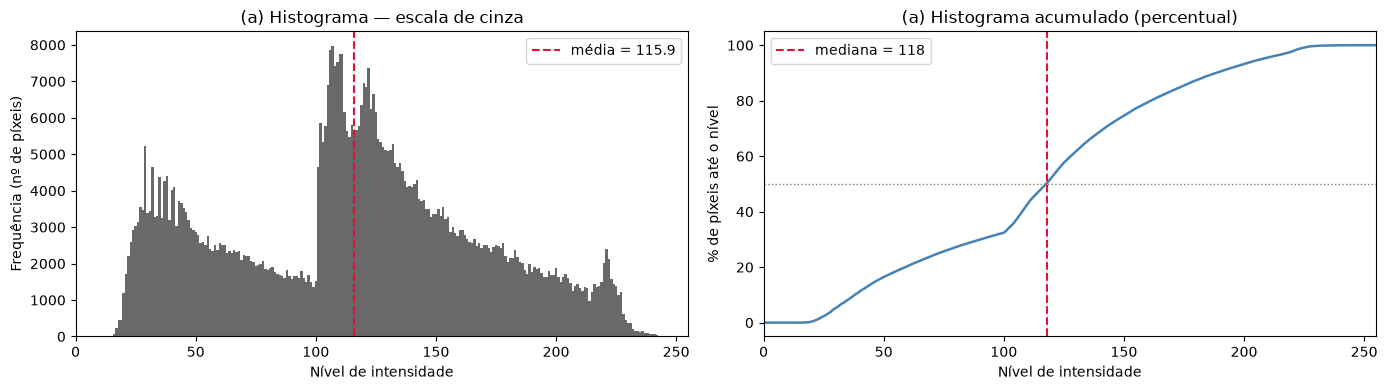

O acumulado cruza 50% no nível 118 — a mediana da imagem.
A curva acumulada é o que se usa em equalização de histograma: ela
indica, para cada nível, que fração da imagem é mais escura que ele.


In [8]:
# --- Item (a): gráficos a partir do CSV ---

x = lido["nivel"]
y = lido["frequencia"]
y_acum = lido["frequencia_acumulada"]

fig, eixos = plt.subplots(1, 2, figsize=(14, 4))

# Histograma
eixos[0].bar(x, y, width=1.0, color="dimgray", edgecolor="none")
eixos[0].axvline(media_hist, color="crimson", linestyle="--",
                 label=f"média = {media_hist:.1f}")
eixos[0].set_title("(a) Histograma — escala de cinza")
eixos[0].set_xlabel("Nível de intensidade")
eixos[0].set_ylabel("Frequência (nº de píxeis)")
eixos[0].set_xlim(0, MAXVAL)
eixos[0].legend()

# Histograma acumulado
eixos[1].plot(x, y_acum / y_acum[-1] * 100, color="steelblue", linewidth=1.8)
eixos[1].axhline(50, color="gray", linestyle=":", linewidth=1)
mediana = int(x[np.searchsorted(y_acum, y_acum[-1] / 2)])
eixos[1].axvline(mediana, color="crimson", linestyle="--",
                 label=f"mediana = {mediana}")
eixos[1].set_title("(a) Histograma acumulado (percentual)")
eixos[1].set_xlabel("Nível de intensidade")
eixos[1].set_ylabel("% de píxeis até o nível")
eixos[1].set_xlim(0, MAXVAL)
eixos[1].legend()

plt.tight_layout()
plt.show()

print(f"O acumulado cruza 50% no nível {mediana} — a mediana da imagem.")
print("A curva acumulada é o que se usa em equalização de histograma: ela")
print("indica, para cada nível, que fração da imagem é mais escura que ele.")

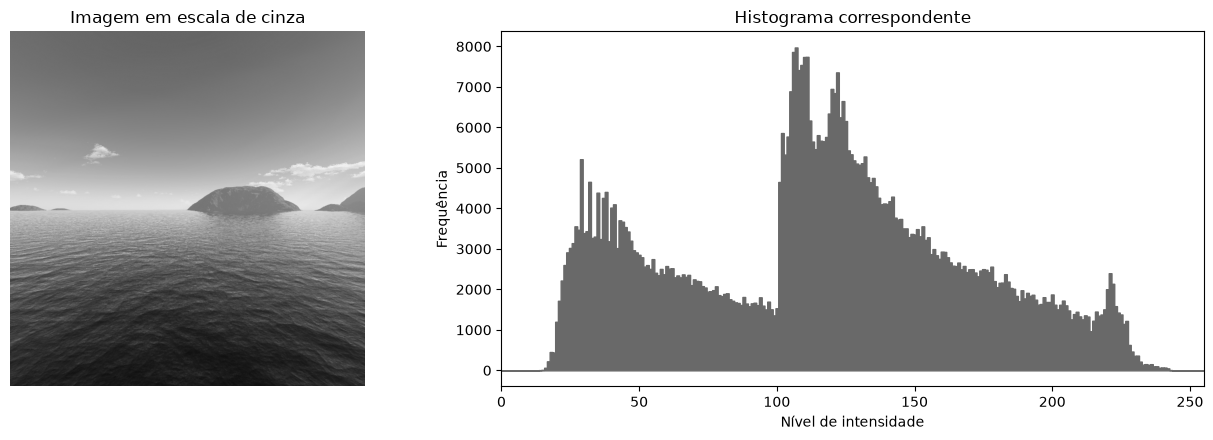

Níveis com frequência zero (25):
  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255]

Todos estão nos extremos da escala — a imagem não possui píxeis
totalmente pretos nem totalmente brancos, o que significa que sua
faixa dinâmica é menor que a disponível no formato.


In [9]:
# --- Item (a): imagem e histograma lado a lado ---

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.5),
                          gridspec_kw={"width_ratios": [1, 1.4]})

eixos[0].imshow(cinza, cmap="gray", vmin=0, vmax=MAXVAL)
eixos[0].set_title("Imagem em escala de cinza")
eixos[0].axis("off")

eixos[1].fill_between(x, y, color="dimgray", step="mid")
eixos[1].set_title("Histograma correspondente")
eixos[1].set_xlabel("Nível de intensidade")
eixos[1].set_ylabel("Frequência")
eixos[1].set_xlim(0, MAXVAL)

plt.tight_layout()
plt.show()

# Onde estão os níveis vazios
vazios_lista = niveis[hist_cinza == 0]
print(f"Níveis com frequência zero ({vazios_lista.size}):")
print(f"  {vazios_lista.tolist()}")
print()
print("Todos estão nos extremos da escala — a imagem não possui píxeis")
print("totalmente pretos nem totalmente brancos, o que significa que sua")
print("faixa dinâmica é menor que a disponível no formato.")

---

## Item (b) — Histogramas dos canais RGB

Mesmo procedimento, aplicado três vezes: cada canal é tratado como uma imagem
independente e gera seu próprio vetor de 256 posições.

O CSV consolida os três em um único arquivo, com uma coluna por canal:

| `nivel` | `frequencia_R` | `frequencia_G` | `frequencia_B` |
|---------|----------------|----------------|----------------|

Manter os três num mesmo arquivo facilita a comparação — abrindo no Excel, basta
selecionar as quatro colunas para plotar as três séries sobrepostas.

Cada coluna deve somar o total de píxeis da imagem, e não o total de valores:
cada píxel contribui com exatamente uma contagem em cada canal.

In [10]:
# --- Item (b): cálculo dos três histogramas ---

CANAIS = ("R", "G", "B")
NOMES = ("Vermelho", "Verde", "Azul")
CORES = ("red", "green", "blue")

n_pixels = rgb.shape[0] * rgb.shape[1]
hists_rgb = [histograma(rgb[:, :, c]) for c in range(3)]

for c, h in enumerate(hists_rgb):
    assert h.sum() == n_pixels, f"Canal {CANAIS[c]}: soma incorreta"
    assert h.size == N_NIVEIS

print(f"Total de píxeis: {n_pixels:,}")
print(f"Cada canal soma: {[int(h.sum()) for h in hists_rgb]}")
print()
print(f"{'Canal':<12}{'Média':>9}{'Desvio':>9}{'Moda':>7}{'Mín':>6}{'Máx':>6}"
      f"{'Ocupados':>10}")
print("-" * 60)
for c, (nome, h) in enumerate(zip(NOMES, hists_rgb)):
    p = h / n_pixels
    m = float((niveis * p).sum())
    d = float(np.sqrt(((niveis - m) ** 2 * p).sum()))
    presentes = niveis[h > 0]
    print(f"{nome:<12}{m:>9.2f}{d:>9.2f}{int(h.argmax()):>7}"
          f"{int(presentes.min()):>6}{int(presentes.max()):>6}"
          f"{int((h > 0).sum()):>10}")

Total de píxeis: 640,000
Cada canal soma: [640000, 640000, 640000]

Canal           Média   Desvio   Moda   Mín   Máx  Ocupados
------------------------------------------------------------
Vermelho        97.33    50.52     84     9   243       235
Verde          116.94    53.88    107    13   244       232
Azul           154.57    56.48    231    22   255       233


In [11]:
# --- Item (b): gravação do CSV ---

CSV_RGB = SAIDA / "b_histograma_rgb.csv"

with open(CSV_RGB, "w", encoding="utf-8", newline="") as f:
    escritor = csv.writer(f)
    escritor.writerow(["nivel", "frequencia_R", "frequencia_G", "frequencia_B",
                       "relativa_R", "relativa_G", "relativa_B"])
    for i in range(N_NIVEIS):
        escritor.writerow([
            i,
            int(hists_rgb[0][i]), int(hists_rgb[1][i]), int(hists_rgb[2][i]),
            f"{hists_rgb[0][i] / n_pixels:.8f}",
            f"{hists_rgb[1][i] / n_pixels:.8f}",
            f"{hists_rgb[2][i] / n_pixels:.8f}",
        ])

print(f"Arquivo gravado : {CSV_RGB.name}")
print(f"Linhas          : {N_NIVEIS} + 1 de cabeçalho")
print(f"Tamanho         : {CSV_RGB.stat().st_size / 1024:.1f} KB")
print()
print("Primeiras linhas:")
print("-" * 74)
with open(CSV_RGB, encoding="utf-8") as f:
    for _ in range(6):
        print(f.readline().rstrip())
print("...")

Arquivo gravado : b_histograma_rgb.csv
Linhas          : 256 + 1 de cabeçalho
Tamanho         : 12.9 KB

Primeiras linhas:
--------------------------------------------------------------------------
nivel,frequencia_R,frequencia_G,frequencia_B,relativa_R,relativa_G,relativa_B
0,0,0,0,0.00000000,0.00000000,0.00000000
1,0,0,0,0.00000000,0.00000000,0.00000000
2,0,0,0,0.00000000,0.00000000,0.00000000
3,0,0,0,0.00000000,0.00000000,0.00000000
4,0,0,0,0.00000000,0.00000000,0.00000000
...


In [12]:
# --- Item (b): releitura e validação ---

lido_rgb = ler_csv_histograma(
    CSV_RGB, ["frequencia_R", "frequencia_G", "frequencia_B"])

for c, canal in enumerate(CANAIS):
    coluna = lido_rgb[f"frequencia_{canal}"].astype(np.int64)
    assert np.array_equal(coluna, hists_rgb[c]), f"Canal {canal} divergiu"
    assert coluna.sum() == n_pixels

print("Round-trip do CSV: OK nos três canais")
for canal in CANAIS:
    soma = int(lido_rgb[f"frequencia_{canal}"].sum())
    print(f"  canal {canal}: {soma:,} contagens")
print()
print("Os gráficos a seguir usam estes dados lidos do disco.")

Round-trip do CSV: OK nos três canais
  canal R: 640,000 contagens
  canal G: 640,000 contagens
  canal B: 640,000 contagens

Os gráficos a seguir usam estes dados lidos do disco.


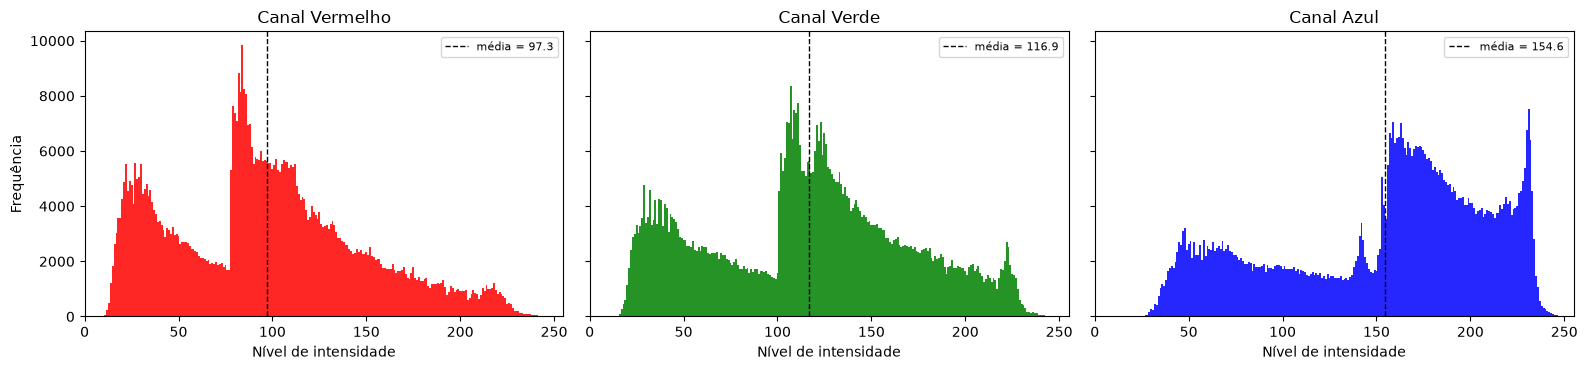

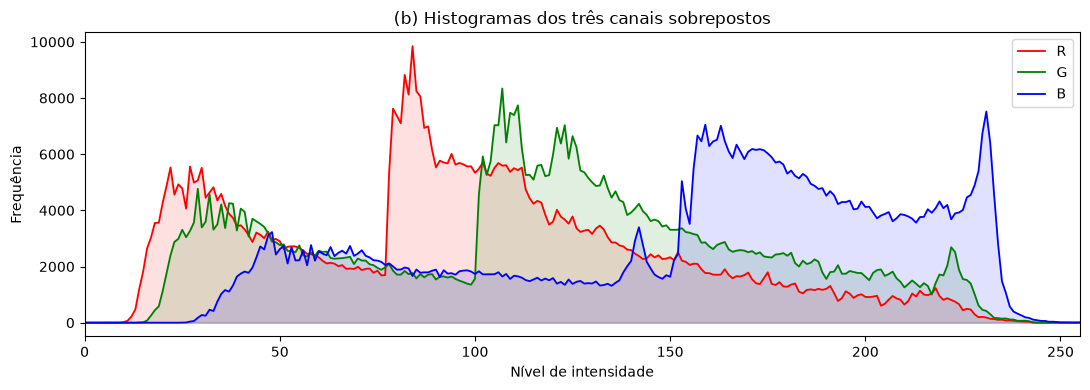

In [13]:
# --- Item (b): gráficos a partir do CSV ---

x = lido_rgb["nivel"]
series = [lido_rgb[f"frequencia_{c}"] for c in CANAIS]

# Três painéis separados, com escala vertical comum para permitir comparação
teto = max(s.max() for s in series) * 1.05
fig, eixos = plt.subplots(1, 3, figsize=(16, 3.8), sharey=True)

for ax, y, nome, cor in zip(eixos, series, NOMES, CORES):
    ax.bar(x, y, width=1.0, color=cor, edgecolor="none", alpha=0.85)
    media_c = float((x * y).sum() / y.sum())
    ax.axvline(media_c, color="black", linestyle="--", linewidth=1,
               label=f"média = {media_c:.1f}")
    ax.set_title(f"Canal {nome}")
    ax.set_xlabel("Nível de intensidade")
    ax.set_xlim(0, MAXVAL)
    ax.set_ylim(0, teto)
    ax.legend(fontsize=8)

eixos[0].set_ylabel("Frequência")
plt.tight_layout()
plt.show()

# Sobreposição das três curvas
fig, ax = plt.subplots(figsize=(11, 4))
for y, canal, cor in zip(series, CANAIS, CORES):
    ax.plot(x, y, color=cor, linewidth=1.3, label=canal)
    ax.fill_between(x, y, color=cor, alpha=0.12)
ax.set_title("(b) Histogramas dos três canais sobrepostos")
ax.set_xlabel("Nível de intensidade")
ax.set_ylabel("Frequência")
ax.set_xlim(0, MAXVAL)
ax.legend()
plt.tight_layout()
plt.show()

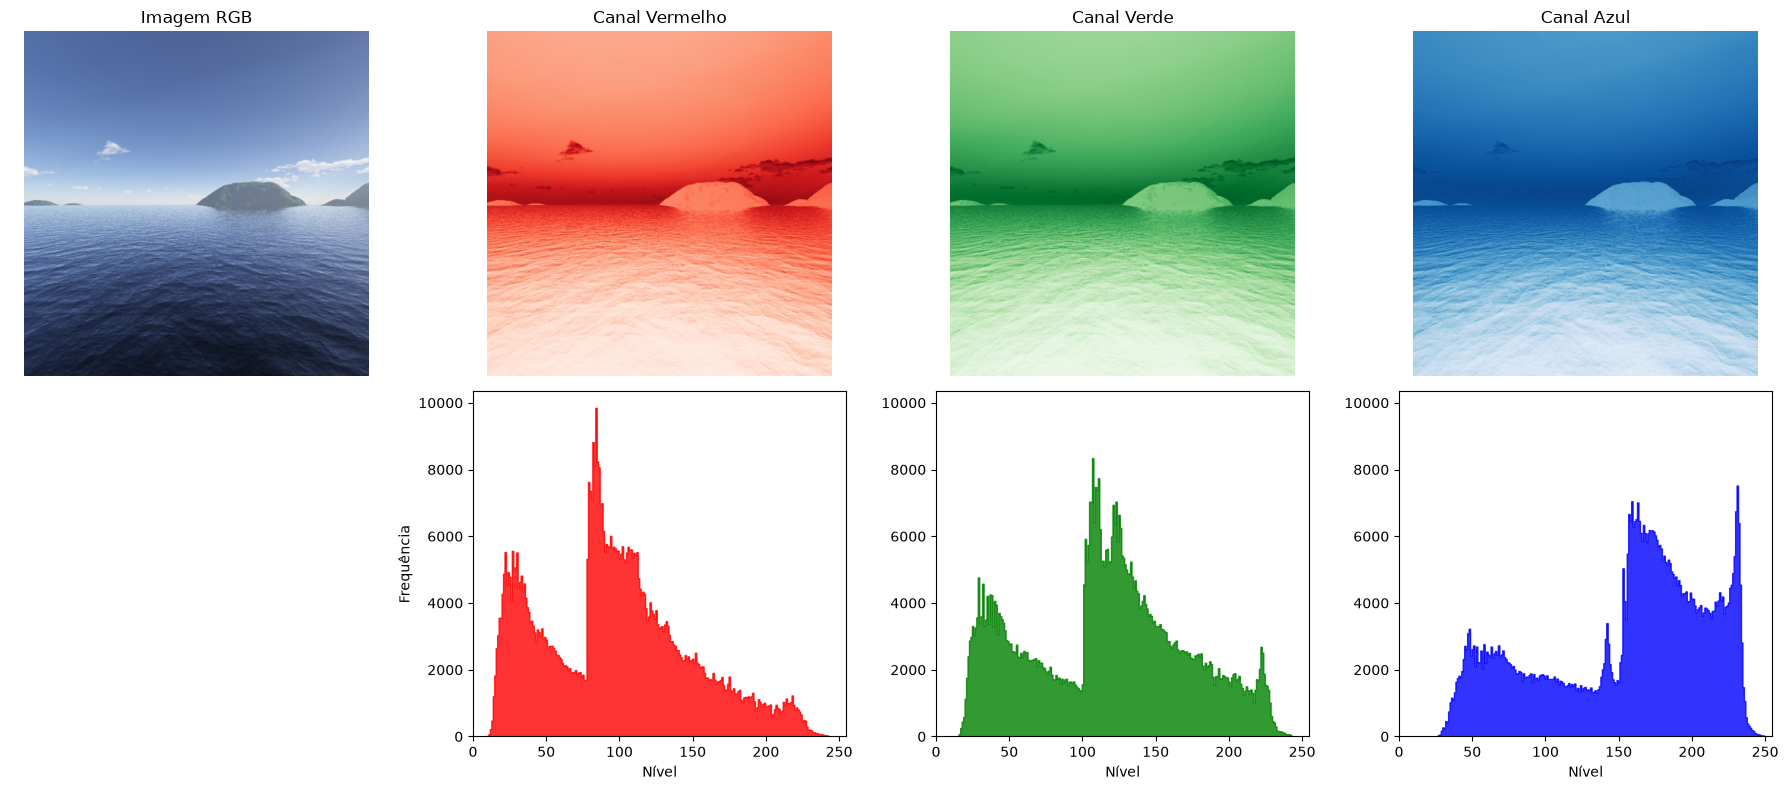

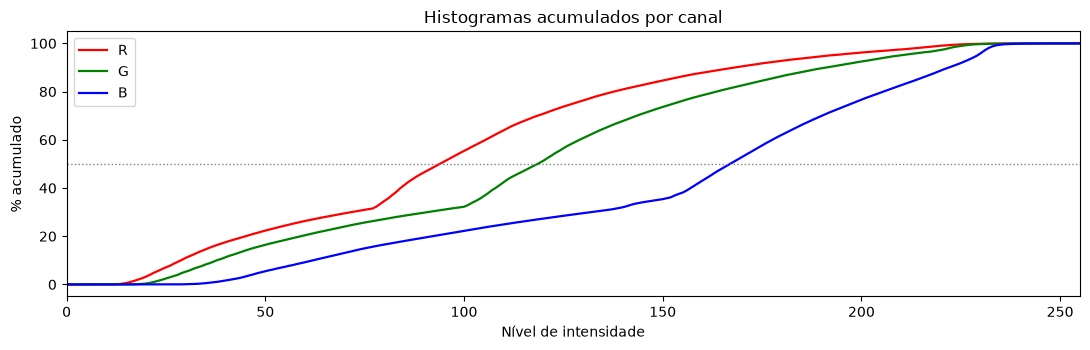

As curvas acumuladas deslocadas entre si indicam desequilíbrio de cor:
quanto mais à direita a curva de um canal, maior a contribuição dele
para a imagem — o que se traduz em dominante daquela cor.


In [14]:
# --- Item (b): imagem, canais e histogramas ---

fig, eixos = plt.subplots(2, 4, figsize=(18, 8))

eixos[0, 0].imshow(rgb / MAXVAL)
eixos[0, 0].set_title("Imagem RGB")
eixos[0, 0].axis("off")

eixos[1, 0].axis("off")

for c, (nome, cor, mapa) in enumerate(zip(NOMES, CORES, ("Reds", "Greens", "Blues"))):
    eixos[0, c + 1].imshow(rgb[:, :, c], cmap=mapa, vmin=0, vmax=MAXVAL)
    eixos[0, c + 1].set_title(f"Canal {nome}")
    eixos[0, c + 1].axis("off")

    eixos[1, c + 1].fill_between(x, series[c], color=cor, step="mid", alpha=0.8)
    eixos[1, c + 1].set_xlim(0, MAXVAL)
    eixos[1, c + 1].set_ylim(0, teto)
    eixos[1, c + 1].set_xlabel("Nível")
    if c == 0:
        eixos[1, c + 1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

# Curvas acumuladas dos três canais
fig, ax = plt.subplots(figsize=(11, 3.6))
for y, canal, cor in zip(series, CANAIS, CORES):
    acum = np.cumsum(y) / y.sum() * 100
    ax.plot(x, acum, color=cor, linewidth=1.6, label=canal)
ax.axhline(50, color="gray", linestyle=":", linewidth=1)
ax.set_title("Histogramas acumulados por canal")
ax.set_xlabel("Nível de intensidade")
ax.set_ylabel("% acumulado")
ax.set_xlim(0, MAXVAL)
ax.legend()
plt.tight_layout()
plt.show()

print("As curvas acumuladas deslocadas entre si indicam desequilíbrio de cor:")
print("quanto mais à direita a curva de um canal, maior a contribuição dele")
print("para a imagem — o que se traduz em dominante daquela cor.")

In [15]:
# --- Verificação final dos arquivos gerados ---

for rotulo, caminho, esperado in [
    ("(a) escala de cinza", CSV_CINZA, [hist_cinza]),
    ("(b) canais RGB", CSV_RGB, hists_rgb),
]:
    with open(caminho, encoding="utf-8", newline="") as f:
        linhas = list(csv.reader(f))

    cabecalho, corpo = linhas[0], linhas[1:]
    print(f"{rotulo}")
    print(f"  arquivo   : {caminho.name}")
    print(f"  colunas   : {cabecalho}")
    print(f"  linhas    : {len(corpo)}")
    print(f"  níveis    : {corpo[0][0]} a {corpo[-1][0]}")
    print(f"  somas     : {[int(h.sum()) for h in esperado]}")
    print(f"  tamanho   : {caminho.stat().st_size / 1024:.1f} KB")
    print()

print("Ambos os CSV contêm as 256 linhas, incluindo os níveis de frequência")
print("zero, e podem ser abertos diretamente em uma planilha para gerar os")
print("mesmos gráficos sem depender deste notebook.")

(a) escala de cinza
  arquivo   : a_histograma_escala_cinza.csv
  colunas   : ['nivel', 'frequencia', 'frequencia_relativa', 'frequencia_acumulada']
  linhas    : 256
  níveis    : 0 a 255
  somas     : [640000]
  tamanho   : 6.7 KB

(b) canais RGB
  arquivo   : b_histograma_rgb.csv
  colunas   : ['nivel', 'frequencia_R', 'frequencia_G', 'frequencia_B', 'relativa_R', 'relativa_G', 'relativa_B']
  linhas    : 256
  níveis    : 0 a 255
  somas     : [640000, 640000, 640000]
  tamanho   : 12.9 KB

Ambos os CSV contêm as 256 linhas, incluindo os níveis de frequência
zero, e podem ser abertos diretamente em uma planilha para gerar os
mesmos gráficos sem depender deste notebook.


---

## Conclusões

### Arquivos gerados

| Item | Arquivo | Conteúdo |
|------|---------|----------|
| (a) | `a_histograma_escala_cinza.csv` | 256 linhas: nível, frequência, relativa, acumulada |
| (b) | `b_histograma_rgb.csv` | 256 linhas: nível e frequência dos três canais |

Ambos validados por releitura: os gráficos do notebook foram construídos a
partir dos dados lidos do disco, não dos arrays em memória, o que comprova que
os arquivos estão corretos e são autossuficientes.

### Sobre a construção do histograma

A verificação decisiva é `Σ h[i] = total de píxeis`. Ela detecta tanto contagens
perdidas quanto duplicadas, e foi aplicada ao histograma em escala de cinza e a
cada um dos três canais.

O ponto de atenção prático é a inclusão dos **níveis de frequência zero**. A
imagem em escala de cinza usada aqui ocupa 231 dos 256 níveis — os 25 restantes,
concentrados nos extremos da escala, não aparecem em nenhum píxel. Montar o
histograma com `np.unique` os eliminaria, deformando o eixo horizontal do
gráfico. `np.bincount(..., minlength=256)` resolve isso por construção.

Esses níveis vazios não são um defeito do método, e sim informação sobre a
imagem: revelam que ela não utiliza toda a faixa dinâmica disponível no formato,
observação que já havia aparecido na Atividade 4 ao discutir a escolha do fator
de conversão.

### O que o histograma diz e o que não diz

O histograma resume 640.000 píxeis em 256 números, preservando integralmente a
distribuição tonal — média e desvio padrão calculados a partir dele coincidem
com os calculados sobre a imagem. Em contrapartida, descarta por completo a
informação espacial: imagens visualmente distintas podem ter histogramas
idênticos.

Essa é exatamente a característica que o torna útil como ferramenta de
diagnóstico e como base de operações que dependem apenas da distribuição, como a
limiarização automática de Otsu empregada na Atividade 05-2 e a equalização de
histograma.

### Sobre os canais RGB

Tratar cada canal separadamente é o procedimento usual, mas convém reconhecer o
que se perde: os três histogramas não registram a **correlação** entre canais.
Eles informam quantos píxeis têm cada valor de R e quantos têm cada valor de B,
mas não quais valores ocorrem juntos. Uma descrição completa exigiria um
histograma tridimensional com 256³ posições — mais de 16 milhões — o que raramente
compensa.

A comparação entre as curvas acumuladas dos três canais é o modo mais direto de
detectar dominante de cor: curvas deslocadas entre si indicam que um canal
contribui sistematicamente mais que os outros para o brilho da imagem.